In [1]:
from scipy.io import loadmat
import spikeinterface as si
import RCP_analysis as rcp
from RCP_analysis.python.functions.config_loading import *

# Local reference params, both floats
RATES = PARAMS.NPRW_rate_est
BIN_MS = 20 #RATES.get("bin_ms")
SIGMA_MS = RATES.get("sigma_ms")
THRESH = RATES.get("detect_threshold")
MS_BEFORE = float(RATES.get("remove_ms_before"))
TAIL_MS = float(RATES.get("remove_tail_ms_after"))
WIN_MS = (-600.0, 600.0)

NPRW_CKPT_OUT = OUT_BASE.parent / 'results' / "checkpoints" / "NPRW"
        
global_job_kwargs = dict(n_jobs=PARAMS.parallel_jobs, chunk_duration=PARAMS.chunk)
si.set_global_job_kwargs(**global_job_kwargs)

In [2]:
INDEX = 1

# 2) Find sessions and load data from each Intan folder
sess_folders = rcp.list_intan_sessions(INTAN_ROOT)
print(f"Found Intan sessions: {len(sess_folders)}")

def _parse_SI_peaks(peaks, n_channels: int) -> tuple[dict[int, np.ndarray], dict[int, np.ndarray]]:
    peak_times: dict[int, np.ndarray] = {i: np.array([], dtype=np.int64) for i in range(n_channels)}
    peak_amp: dict[int, np.ndarray] = {i: np.array([], dtype=np.float32) for i in range(n_channels)}

    ch_idx = peaks["channel_index"]
    for i in np.unique(ch_idx):
        ii = int(i)
        if ii >= n_channels:
            continue
        m = (ch_idx == i)
        peak_times[ii] = peaks["sample_index"][m]
        peak_amp[ii] = peaks["amplitude"][m]

    return peak_times, peak_amp

PERI_ROOT = OUT_BASE / "checkpoints" / "PeriStim"
STIM_PERI_ROOT  = PERI_ROOT / "stim_reaches"

stim_dir = STIM_PERI_ROOT #/ 'target_A'

Found Intan sessions: 63


In [3]:
# Jax imports
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import matplotlib.pyplot as plt
from jax import vmap, value_and_grad, jit
from jax.nn import softplus
from tensorflow_probability.substrates.jax.distributions import Poisson

from dynamax.generalized_gaussian_ssm import (
    ParamsGGSSM, GeneralizedGaussianSSM, EKFIntegrals,
    conditional_moments_gaussian_smoother as cmgs,
)
from dynamax.utils.utils import random_rotation

In [ ]:
import json
# Sessions to treat as control (index into nprw_pp_folders); rest are stim
CONTROL_INDICES = [0]
SKIP_INDICES    = [62]

# Paths
PERI_ROOT      = OUT_BASE / "checkpoints" / "PeriStim"
STIM_PERI_ROOT = PERI_ROOT / "stim_reaches"
CTRL_PERI_ROOT = PERI_ROOT / "control_reaches"

nprw_pp_folders  = sorted(NPRW_CKPT_OUT.glob("pp_*"))
nprw_peaks_files = sorted(NPRW_CKPT_OUT.glob(f"rates__*bin{BIN_MS}ms*.npz"))
assert len(nprw_pp_folders) == len(nprw_peaks_files), "Mismatch between pp_ and rates__ files"

# Resolve stim_dur once from the first non-control session
stim_dur_global = None
for idx, nprw_peaks_folder in enumerate(nprw_peaks_files):
    if idx not in CONTROL_INDICES:
        _npz = np.load(list(STIM_PERI_ROOT.glob(
            f"peristim__NRR_RW{nprw_pp_folders[idx].name.split('NRR_RW',1)[1]}__BR_*.npz"
        ))[0], allow_pickle=True)
        stim_dur_global = float(json.loads(_npz['meta_json'].item())['recording_stim_dur'])
        print(f"stim_dur_global resolved from idx={idx}: {stim_dur_global} ms")
        break

stim_dur = stim_dur_global

stim_dur_global resolved from idx=1: 17.933333333333334 ms


In [5]:
all_observations_list = []
stim_ind_list         = []
trial_labels_list     = []   # 0=control, 1=stim
session_labels_list   = []   # index into nprw_pp_folders
centers_ms_by_session = {}
edges_ms_by_session   = {}

for idx, (nprw_pp_folder, nprw_peaks_folder) in enumerate(zip(nprw_pp_folders, nprw_peaks_files)):
    if idx in SKIP_INDICES:
        print(f"[{idx}] SKIPPED")
        continue
    is_control = idx in CONTROL_INDICES
    # Load peaks
    nprw_peaks_si_obj = np.load(nprw_peaks_folder, allow_pickle=True)
    nprw_peak_samps, _ = _parse_SI_peaks(nprw_peaks_si_obj['peaks'], 128)
    nprw_peak_ms = {k: (v / 30000) * 1000.0 for k, v in nprw_peak_samps.items()}
    SESSION = nprw_peaks_si_obj['meta'].item()['session']

    session_name = nprw_pp_folder.name.split("NRR_RW", 1)[1]

    if is_control:
        peri_dir = CTRL_PERI_ROOT
        glob_pat = f"peristim__NRR_RW*.npz"
    else:
        peri_dir = STIM_PERI_ROOT
        glob_pat = f"peristim__NRR_RW{session_name}__BR_*.npz"

    matches = list(peri_dir.glob(glob_pat))
    if not matches:
        print(f"  WARNING: no peristim file found for idx={idx}, skipping")
        continue
    npz_path = matches[0]
    npz      = np.load(npz_path, allow_pickle=True)

    if is_control:
        event_ms = npz['event_ms']
        peak_ms_dedup = npz['NPRW_peak_ms_dedup']
        if isinstance(peak_ms_dedup, np.ndarray) and peak_ms_dedup.dtype == object:
            peak_ms_dedup = peak_ms_dedup.item()

        counts_ch, centers_ms, edges_ms, _ = rcp.bin_counts_around_stim(
            peak_ms_dedup, BIN_MS, event_ms,
            MS_BEFORE, (stim_dur + TAIL_MS), WIN_MS
        )
    else:
        counts_ch  = npz['NPRW_counts']        # (n_trials, n_ch, n_bins)
        centers_ms = npz["NPRW_rel_t"]
        edges_ms   = npz["NPRW_edges_ms"]
    centers_ms_by_session[idx] = centers_ms
    edges_ms_by_session[idx]   = edges_ms

    meta       = json.loads(npz['meta_json'].item())
    # stim_dur   = meta.get("recording_stim_dur", 0)
    nprw_meta  = json.loads(npz["nprw_meta_json"].item())
    stim_ch_0  = np.asarray(nprw_meta["stim_channels"], dtype=int) - 1

    n_trials_i, n_ch, n_bins = counts_ch.shape
    ir_idx = int(jnp.argmin(jnp.abs(jnp.array(centers_ms))))

    # stim_ind: zeros for control, pulse at ir_idx for stim
    stim_ind = jnp.zeros((n_trials_i, n_bins, n_ch))
    if not is_control:
        stim_ind = stim_ind.at[:, ir_idx, stim_ch_0].set(1.0)

    obs = jnp.array(counts_ch.transpose(0, 2, 1))  # (n_trials, n_bins, n_ch)

    all_observations_list.append(obs)
    stim_ind_list.append(stim_ind)
    trial_labels_list.append(jnp.full(n_trials_i, 0 if is_control else 1, dtype=jnp.int32))
    session_labels_list.append(jnp.full(n_trials_i, idx, dtype=jnp.int32))

# Concatenate across all sessions
all_observations_combined_before = jnp.concatenate(all_observations_list, axis=0)
stim_ind_combined         = jnp.concatenate(stim_ind_list,         axis=0)
trial_labels              = jnp.concatenate(trial_labels_list,      axis=0)
session_labels            = jnp.concatenate(session_labels_list,    axis=0)

print(f"all_observations_combined: {all_observations_combined_before.shape}")
print(f"stim_ind_combined:         {stim_ind_combined.shape}")
print(f"trial_labels:              {trial_labels.shape}  (0=ctrl, 1=stim)")
print(f"session_labels:            {session_labels.shape}  unique={jnp.unique(session_labels)}")

[62] SKIPPED
all_observations_combined: (788, 57, 128)
stim_ind_combined:         (788, 57, 128)
trial_labels:              (788,)  (0=ctrl, 1=stim)
session_labels:            (788,)  unique=[ 0  1  2  3  4  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53 54 55 56 57 58 59 60 61]


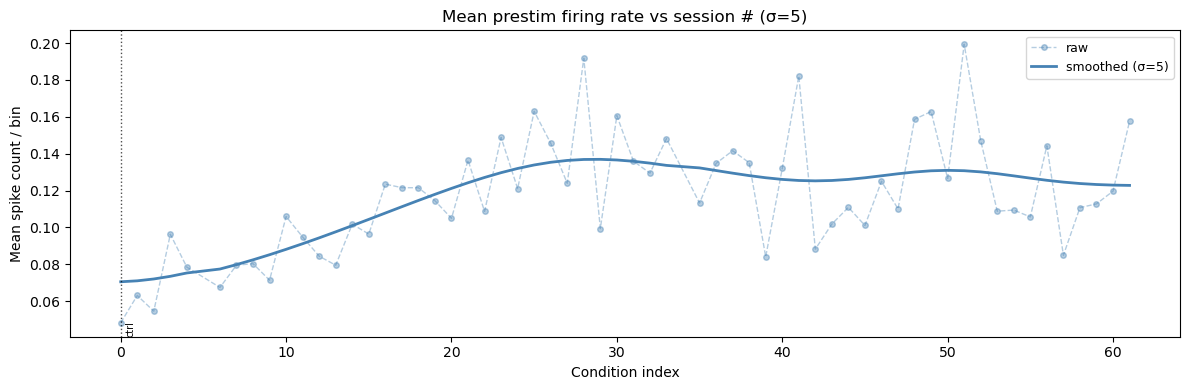

In [6]:
%matplotlib inline
from scipy.ndimage import gaussian_filter1d

DRIFT_SIGMA_SESSIONS = 5

# Prestim mask from the first session's centers_ms
_centers = list(centers_ms_by_session.values())[0]
prestim_mask = _centers < 0  # (n_bins,)

trial_mean_fr = np.array(all_observations_combined_before)[:, prestim_mask, :].mean(axis=1)  # (n_trials, n_ch)

session_labels_np = np.array(session_labels)
unique_sessions = np.unique(session_labels_np)

# One scalar per session: mean across trials AND channels
session_mean_fr = np.array([
    trial_mean_fr[session_labels_np == s].mean()
    for s in unique_sessions
])

smoothed = gaussian_filter1d(session_mean_fr, sigma=DRIFT_SIGMA_SESSIONS)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(unique_sessions, session_mean_fr, color="steelblue", alpha=0.4, lw=1.0, ls="--", marker="o", ms=4, label="raw")
ax.plot(unique_sessions, smoothed,        color="steelblue", alpha=1.0, lw=2.0, label=f"smoothed (σ={DRIFT_SIGMA_SESSIONS})")

for s in unique_sessions:
    if int(s) in CONTROL_INDICES:
        ax.axvline(s, color="black", lw=1.0, ls=":", alpha=0.7)
        ax.text(s + 0.3, ax.get_ylim()[0], "ctrl", fontsize=7, va="bottom", rotation=90)

ax.set_xlabel("Condition index")
ax.set_ylabel("Mean spike count / bin")
ax.set_title(f"Mean prestim firing rate vs session # (σ={DRIFT_SIGMA_SESSIONS})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
session_mean_fr_by_ch = np.array([
    trial_mean_fr[session_labels_np == s].mean(axis=0)
    for s in unique_sessions
])
session_smoothed_by_ch = gaussian_filter1d(session_mean_fr_by_ch, sigma=DRIFT_SIGMA_SESSIONS, axis=0)

session_idx_to_pos = {int(s): i for i, s in enumerate(unique_sessions)}

session_smoothed_by_ch_safe = np.clip(session_smoothed_by_ch, 1e-6, None)

# Reference: smoothed prestim mean per channel for the first control session
ctrl_session_idx = CONTROL_INDICES[0]
ctrl_pos = session_idx_to_pos[ctrl_session_idx]
ctrl_mean_by_ch = session_smoothed_by_ch_safe[ctrl_pos]  # (n_ch,)

scale_factors = np.array([
    ctrl_mean_by_ch / session_smoothed_by_ch_safe[session_idx_to_pos[int(s)]]
    for s in session_labels_np
])  # (n_trials, n_ch)

scale_factors = scale_factors[:, None, :]  # (n_trials, 1, n_ch)

all_observations_corrected = jnp.array(
    np.array(all_observations_combined_before) * scale_factors
)

print(f"min before: {float(all_observations_combined_before.min()):.3f}  min after: {float(all_observations_corrected.min()):.3f}")
print(f"max before: {float(all_observations_combined_before.max()):.3f}  max after: {float(all_observations_corrected.max()):.3f}")
print(f"scale factor range: [{scale_factors.min():.3f}, {scale_factors.max():.3f}]")

all_observations_combined = all_observations_corrected

min before: 0.000  min after: 0.000
max before: 12.000  max after: 12.366
scale factor range: [0.074, 4.793]


## Fit together

In [8]:
key = jr.key(0)
key1, key2 = jr.split(key, 2)

state_dim = 4
num_trials, num_timesteps, n_ch = all_observations_combined.shape

In [ ]:
# Initialization
C_init = 0.5 * jr.normal(key2, shape=(n_ch, state_dim))
all_observations_control = all_observations_combined[trial_labels == 0]
d_init = jnp.mean(all_observations_control, axis=(0, 1))
log_d_init = jnp.log(d_init)
A_init = jnp.eye(state_dim)
B_init = jnp.zeros((state_dim, n_ch)) + 0.01 * jr.normal(key2, shape=(state_dim, n_ch))
K_init = jnp.zeros(state_dim)  # step gain
mu0_init = jnp.zeros(state_dim)
theta = (C_init, log_d_init, A_init, B_init, K_init, mu0_init)

def make_params(C, d, A, B, K, mu0):
    return ParamsGGSSM(
        initial_mean=mu0,
        initial_covariance=jnp.eye(state_dim),
        dynamics_function=lambda z, u: A @ z + B @ u[:-1] + K * u[-1],  # u[-1] is the step scalar
        dynamics_covariance=0.001 * jnp.eye(state_dim),
        emission_mean_function=lambda z, u: softplus(C @ z + d),
        emission_cov_function=lambda z, u: jnp.diag(softplus(C @ z + d)),
        emission_dist=lambda mu, Sigma: Poisson(rate=mu),
    )

def loss_fn(theta, observations, inputs):
    C, log_d, A, B, K, mu0 = theta
    sigma_max = jnp.linalg.norm(A, ord=2)
    penalty_A = 1e2 * jnp.maximum(0.0, sigma_max - 1.0) ** 2
    params = make_params(C, jnp.exp(log_d), A, B, K, mu0)
    posts = vmap(lambda obs, inp: cmgs(params, EKFIntegrals(), obs, inputs=inp))(observations, inputs)
    return -jnp.sum(posts.marginal_loglik) + penalty_A

optimizer = optax.adam(10e-3)
opt_state = optimizer.init(theta)
BATCH_SIZE = 32

@jit
def step_batch(theta, opt_state, obs_batch, inp_batch):
    loss, grads = value_and_grad(loss_fn)(theta, obs_batch, inp_batch)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    new_theta = optax.apply_updates(theta, updates)
    return new_theta, new_opt_state, loss

n_trials_total = all_observations_combined.shape[0]
indices = jnp.arange(n_trials_total)

step = (jnp.arange(n_bins) >= ir_idx).astype(jnp.float32)
step_input = jnp.broadcast_to(step[None, :, None], (n_trials_total, n_bins, 1))
stim_ind_combined_step = jnp.concatenate([stim_ind_combined, step_input], axis=-1)

losses = []
n_epochs = 400

for epoch in range(n_epochs):
    perm = jr.permutation(jr.key(epoch), indices)
    epoch_loss = 0.0
    n_batches = 0
    for start in range(0, n_trials_total, BATCH_SIZE):
        batch_idx = perm[start:start + BATCH_SIZE]
        obs_batch = all_observations_combined[batch_idx]
        inp_batch = stim_ind_combined_step[batch_idx]
        theta, opt_state, loss = step_batch(theta, opt_state, obs_batch, inp_batch)
        epoch_loss += float(loss)
        n_batches += 1
    losses.append(epoch_loss / n_batches)
    if epoch % 50 == 0:
        C_cur, log_d_cur, A_cur, B_cur, K_cur, mu0_cur = theta
        print(f"epoch {epoch:4d}  loss={losses[-1]:.2f}  B_norm={jnp.linalg.norm(B_cur):.4f}  K_norm={jnp.linalg.norm(K_cur):.4f}")

C_fit_combined, log_d_fit_combined, A_fit_combined, B_fit_combined, K_fit_combined, mu0_fit_combined = theta

epoch    0  loss=136517.83  B_norm=0.6326  K_norm=0.0189
epoch   50  loss=58188.23  B_norm=3.2229  K_norm=0.0381
epoch  100  loss=58066.08  B_norm=4.0545  K_norm=0.0440
epoch  150  loss=58039.27  B_norm=5.1833  K_norm=0.0484
epoch  200  loss=57994.19  B_norm=6.2619  K_norm=0.0431
epoch  250  loss=57997.22  B_norm=6.9268  K_norm=0.0397
epoch  300  loss=57996.18  B_norm=7.3432  K_norm=0.0395
epoch  350  loss=58008.94  B_norm=7.6518  K_norm=0.0367


In [14]:
# Get latent trajectories
params_fit_combined = make_params(C_fit_combined, jnp.exp(log_d_fit_combined), A_fit_combined, B_fit_combined, K_fit_combined, mu0_fit_combined)
posts_fit_combined = vmap(lambda obs, input: cmgs(params_fit_combined, EKFIntegrals(), obs, inputs=input))(all_observations_combined, stim_ind_combined_step)
predicted_all_combined = softplus(posts_fit_combined.filtered_means @ C_fit_combined.T + jnp.exp(log_d_fit_combined))
innovations_all_combined = all_observations_combined - predicted_all_combined
t = jnp.arange(all_observations_combined.shape[1])
n_latents = posts_fit_combined.filtered_covariances.shape[-1]
U, S, Vt = jnp.linalg.svd(C_fit_combined, full_matrices=False)
R = Vt.T
z_combined = posts_fit_combined.filtered_means @ R
top_dims_rot = jnp.arange(n_latents)

## Split up control and stim

In [15]:
unique_sessions = jnp.unique(session_labels)
obs_by_session      = {}
stim_ind_by_session = {}
posts_by_session    = {}
z_by_session        = {}
predicted_by_session    = {}
innovations_by_session  = {}

for sess_idx in unique_sessions:
    mask = session_labels == sess_idx
    sess_idx = int(sess_idx)
    obs_by_session[sess_idx]         = all_observations_combined[mask]
    stim_ind_by_session[sess_idx]    = stim_ind_combined_step[mask]  # updated
    posts_by_session[sess_idx]       = jax.tree.map(lambda x: x[mask], posts_fit_combined)
    z_by_session[sess_idx]           = z_combined[mask]
    predicted_by_session[sess_idx]   = predicted_all_combined[mask]
    innovations_by_session[sess_idx] = innovations_all_combined[mask]

control_mask = trial_labels == 0
stim_mask    = trial_labels == 1
z_control = z_combined[control_mask]
z_stim    = z_combined[stim_mask]
innovations_control = innovations_all_combined[control_mask]
innovations_stim    = innovations_all_combined[stim_mask]

## Plots

In [16]:
import plotly.graph_objects as go

def plot_latent_phase_portrait_sessions(
    z_by_session,
    centers_ms_by_session,
    control_indices,
    alpha_trials=0.15,
    plot_sessions=None,
    epoch="full",
    pre_trim_bins=0,
    post_trim_bins=0,
    show_trials=True,
    show_markers=True,
    show_pre_post=False,  # if True, pre=desaturated, post=full color
    x_range=None,
    y_range=None,
    z_range=None,
):
    if plot_sessions is None:
        plot_sessions = sorted(z_by_session.keys())

    gap_bin_by_session = {}
    for k in plot_sessions:
        cms = centers_ms_by_session[k]
        gap_bin_by_session[k] = int(np.argmax(np.diff(cms))) + 1  # first post-gap bin index

    def slice_epoch(z, cms, gap_bin):
        if epoch == "pre":
            end = gap_bin - pre_trim_bins
            return z[:, :end, :], cms[:end]
        elif epoch == "post":
            start = gap_bin + post_trim_bins
            return z[:, start:, :], cms[start:]
        return z, cms

    colorscale = plt.cm.jet(np.linspace(0.05, 0.9, len(plot_sessions)))
    fig = go.Figure()

    for i, sess_idx in enumerate(plot_sessions):
        z         = z_by_session[sess_idx]
        cms       = centers_ms_by_session[sess_idx]
        gap_bin   = gap_bin_by_session[sess_idx]
        is_ctrl   = sess_idx in control_indices
        color_rgb = "rgb(0,0,0)" if is_ctrl else f"rgb({int(colorscale[i,0]*255)},{int(colorscale[i,1]*255)},{int(colorscale[i,2]*255)})"
        label     = f"{'ctrl' if is_ctrl else 'stim'} [{sess_idx}]"

        z_ep, cms_ep = slice_epoch(z, cms, gap_bin)
        ir_idx = int(np.argmin(np.abs(cms_ep)))

        mean_z = z_ep.mean(axis=0)
        x, y, zz = mean_z[:, 0], mean_z[:, 1], mean_z[:, 2]
        if show_trials:
            for trial in range(z_ep.shape[0]):
                fig.add_trace(go.Scatter3d(
                    x=z_ep[trial, :, 0], y=z_ep[trial, :, 1], z=z_ep[trial, :, 2],
                    mode="lines",
                    line=dict(color=color_rgb, width=1),
                    opacity=alpha_trials,
                    showlegend=False,
                ))
        if show_pre_post and epoch == "full":
            x_pre,  y_pre,  zz_pre  = x[:gap_bin], y[:gap_bin], zz[:gap_bin]
            x_post, y_post, zz_post = x[gap_bin:],  y[gap_bin:],  zz[gap_bin:]
            mode = "lines" if not show_markers else "markers+lines"

            fig.add_trace(go.Scatter3d(
                x=x_pre, y=y_pre, z=zz_pre,
                mode=mode,
                marker=dict(size=3, color=color_rgb),
                line=dict(color=color_rgb, width=2, dash="dash"),
                name=label + " pre",
                showlegend=False,
            ))
            fig.add_trace(go.Scatter3d(
                x=x_post, y=y_post, z=zz_post,
                mode=mode,
                marker=dict(size=3, color=cms_ep, colorscale="Viridis", showscale=(i == 0),
                    colorbar=dict(title="Time (ms)", thickness=15, x=1.0)),
                line=dict(color=color_rgb, width=3),
                name=label,
            ))
        else:
            x_plot, y_plot, z_plot = x, y, zz
            if epoch == "full":
                x_plot = np.insert(np.array(x), gap_bin, np.nan)
                y_plot = np.insert(np.array(y), gap_bin, np.nan)
                z_plot = np.insert(np.array(zz), gap_bin, np.nan)

            fig.add_trace(go.Scatter3d(
                x=x_plot, y=y_plot, z=z_plot,
                mode="lines" if not show_markers else "markers+lines",
                marker=dict(size=3, color=cms_ep, colorscale="Viridis", showscale=(i == 0),
                    colorbar=dict(title="Time (ms)", thickness=15, x=1.0)),
                line=dict(color=color_rgb, width=3),
                name=label,
            ))

        if show_markers:
            if epoch in ("post", "full"):
                fig.add_trace(go.Scatter3d(
                    x=[x[ir_idx]], y=[y[ir_idx]], z=[zz[ir_idx]],
                    mode="markers",
                    marker=dict(size=6, color=color_rgb, symbol="diamond"),
                    line=dict(width=0),
                    showlegend=False,
                ))
            fig.add_trace(go.Scatter3d(
                x=[x[0]], y=[y[0]], z=[zz[0]],
                mode="markers",
                marker=dict(size=6, color=color_rgb, symbol="circle"),
                line=dict(width=0),
                showlegend=False,
            ))
            
    fig.update_layout(
        title=f"Latent trajectories — {epoch} stim",
        scene=dict(
            xaxis=dict(title="z₁", **({"range": x_range} if x_range else {})),
            yaxis=dict(title="z₂", **({"range": y_range} if y_range else {})),
            zaxis=dict(title="z₃", **({"range": z_range} if z_range else {})),
            aspectmode="cube",
        ),
        legend=dict(itemsizing="constant", x=1.15, y=0.4),
        margin=dict(l=0, r=0, b=0, t=40),
        width=1000, height=800,
    )
    return fig

In [17]:
# All sessions, post-stim only
fig = plot_latent_phase_portrait_sessions(
    z_by_session=z_by_session,
    centers_ms_by_session=centers_ms_by_session,
    control_indices=CONTROL_INDICES,
    alpha_trials=0.05,
    plot_sessions=None,  # or e.g. [0, 1, 2, 5]
    epoch="pre",        # "full", "pre", or "post"
    show_trials=False,
    show_markers=False,
)
fig.update_layout(scene_camera=dict(eye=dict(x=1.75, y=0.75, z=0.75), center=dict(x=0, y=0, z=-0.2)))
fig.show()

In [16]:
# fig.write_image("NPRW_trajectory_combined_prestim.png", scale=2)  # scale=2 doubles DPI]
# fig.write_html("NPRW_trajectory_combined_prestim.html", include_plotlyjs=True, full_html=True)

In [18]:
# All sessions, post-stim only
fig = plot_latent_phase_portrait_sessions(
    z_by_session=z_by_session,
    centers_ms_by_session=centers_ms_by_session,
    control_indices=CONTROL_INDICES,
    alpha_trials=0.05,
    plot_sessions=None,  # or e.g. [0, 1, 2, 5]
    epoch="post",        # "full", "pre", or "post"
    show_trials=False,
    show_markers=False,
)
fig.update_layout(scene_camera=dict(eye=dict(x=1.75, y=0.75, z=0.75), center=dict(x=0, y=0, z=-0.2)))
fig.show()

In [18]:
# fig.write_image("NPRW_trajectory_combined_poststim.png", scale=2)  # scale=2 doubles DPI]
# fig.write_html("NPRW_trajectory_combined_poststim.html", include_plotlyjs=True, full_html=True)

In [20]:
# All sessions, post-stim only
fig = plot_latent_phase_portrait_sessions(
    z_by_session=z_by_session,
    centers_ms_by_session=centers_ms_by_session,
    control_indices=CONTROL_INDICES,
    alpha_trials=0.05,
    plot_sessions=None,  # or e.g. [0, 1, 2, 5]
    pre_trim_bins=0,
    post_trim_bins=0,
    epoch="full",        # "full", "pre", or "post"
    show_pre_post=True,
    show_trials=False,
    show_markers=False,
)
fig.update_layout(scene_camera=dict(eye=dict(x=1.75, y=0.75, z=0.75), center=dict(x=0, y=0, z=-0.2)))
fig.show()

In [20]:
# fig.write_image("NPRW_trajectory_combined_full.png", scale=2)  # scale=2 doubles DPI]
# fig.write_html("NPRW_trajectory_combined_full.html", include_plotlyjs=True, full_html=True)

In [21]:
# All sessions, post-stim only
fig = plot_latent_phase_portrait_sessions(
    z_by_session=z_by_session,
    centers_ms_by_session=centers_ms_by_session,
    control_indices=CONTROL_INDICES,
    alpha_trials=0.05,
    plot_sessions = [0] +list(range(2, 5)) + list(range(6, 21)),  # or e.g. [0, 1, 2, 5]
    pre_trim_bins=0,
    post_trim_bins=0,
    epoch="full",        # "full", "pre", or "post"
    show_pre_post=True,
    show_trials=False,
    show_markers=True,
)
fig.update_layout(scene_camera=dict(eye=dict(x=1.75, y=0.75, z=0.75), center=dict(x=0, y=0, z=-0.2)))
fig.show()

In [22]:
# fig.write_image("NPRW_trajectory_combined_20_trials.png", scale=2)  # scale=2 doubles DPI]
# fig.write_html("NPRW_trajectory_combined_20_trials.html", include_plotlyjs=True, full_html=True)

## Plot 10 trials

In [22]:
# All sessions, post-stim only
fig = plot_latent_phase_portrait_sessions(
    z_by_session=z_by_session,
    centers_ms_by_session=centers_ms_by_session,
    control_indices=CONTROL_INDICES,
    alpha_trials=0.05,
    plot_sessions = [0] +list(range(2, 5)) + list(range(6, 13)),
    pre_trim_bins=0,
    post_trim_bins=0,
    epoch="full",        # "full", "pre", or "post"
    show_pre_post=False,
    show_trials=False,
    show_markers=True,
)
fig.update_layout(scene_camera=dict(eye=dict(x=1.75, y=0.75, z=0.75), center=dict(x=0, y=0, z=-0.2)))
fig.show()

In [23]:
# All sessions, post-stim only
fig = plot_latent_phase_portrait_sessions(
    z_by_session=z_by_session,
    centers_ms_by_session=centers_ms_by_session,
    control_indices=CONTROL_INDICES,
    alpha_trials=0.05,
    plot_sessions = [0] +list(range(2, 5)) + list(range(6, 13)),
    epoch="pre",        # "full", "pre", or "post"
    pre_trim_bins=0,
    post_trim_bins=0,
    show_trials=False,
    show_markers=False,
)
fig.update_layout(scene_camera=dict(eye=dict(x=1.75, y=0.75, z=0.75), center=dict(x=0, y=0, z=-0.2)))
fig.show()

In [25]:
# fig.write_image("NPRW_trajectory_combined_prestim_10_trials.png", scale=2)  # scale=2 doubles DPI]
# fig.write_html("NPRW_trajectory_combined_prestim_10_trials.html", include_plotlyjs=True, full_html=True)

In [24]:
# All sessions, post-stim only
fig = plot_latent_phase_portrait_sessions(
    z_by_session=z_by_session,
    centers_ms_by_session=centers_ms_by_session,
    control_indices=CONTROL_INDICES,
    alpha_trials=0.05,
    plot_sessions = [0] +list(range(2, 5)) + list(range(6, 13)),
    epoch="post",        # "full", "pre", or "post"
    pre_trim_bins=0,
    post_trim_bins=0,
    show_trials=False,
    show_markers=False,
)
fig.update_layout(scene_camera=dict(eye=dict(x=1.75, y=0.75, z=0.75), center=dict(x=0, y=0, z=-0.2)))
fig.show()

In [27]:
# fig.write_image("NPRW_trajectory_combined_poststim_10_trials.png", scale=2)  # scale=2 doubles DPI]
# fig.write_html("NPRW_trajectory_combined_poststim_10_trials.html", include_plotlyjs=True, full_html=True)

In [25]:
# All sessions, post-stim only
fig = plot_latent_phase_portrait_sessions(
    z_by_session=z_by_session,
    centers_ms_by_session=centers_ms_by_session,
    control_indices=CONTROL_INDICES,
    alpha_trials=0.05,
    plot_sessions = [0] +list(range(2, 5)) + list(range(6, 13)),
    epoch="full",        # "full", "pre", or "post"
    pre_trim_bins=0,
    post_trim_bins=0,
    show_pre_post=True,
    show_trials=False,
    show_markers=True,
)
fig.update_layout(scene_camera=dict(eye=dict(x=1.75, y=0.75, z=0.75), center=dict(x=0, y=0, z=-0.2)))
fig.show()

In [29]:
# fig.write_image("NPRW_trajectory_combined_full_10_trials.png", scale=2)  # scale=2 doubles DPI]
# fig.write_html("NPRW_trajectory_combined_full_10_trials.html", include_plotlyjs=True, full_html=True)

## Plot 3 trials

In [26]:
# All sessions, post-stim only
fig = plot_latent_phase_portrait_sessions(
    z_by_session=z_by_session,
    centers_ms_by_session=centers_ms_by_session,
    control_indices=CONTROL_INDICES,
    alpha_trials=0.05,
    plot_sessions = [0] +list(range(2, 4)),
    epoch="pre",        # "full", "pre", or "post"
    pre_trim_bins=0,
    post_trim_bins=0,
    show_trials=False,
    show_markers=True,
)
fig.update_layout(scene_camera=dict(eye=dict(x=1.75, y=0.75, z=0.75), center=dict(x=0, y=0, z=-0.2)))
fig.show()

In [31]:
# fig.write_image("NPRW_trajectory_combined_prestim_3_trials_with_markers.png", scale=2)  # scale=2 doubles DPI]
# fig.write_html("NPRW_trajectory_combined_prestim_3_trials_with_markers.html", include_plotlyjs=True, full_html=True)

In [27]:
# All sessions, post-stim only
fig = plot_latent_phase_portrait_sessions(
    z_by_session=z_by_session,
    centers_ms_by_session=centers_ms_by_session,
    control_indices=CONTROL_INDICES,
    alpha_trials=0.05,
    plot_sessions = [0] +list(range(2, 4)),
    epoch="full",        # "full", "pre", or "post"
    pre_trim_bins=0,
    post_trim_bins=0,
    show_pre_post=False,
    show_trials=False,
    show_markers=True,
    # x_range=[2, 4],
    # y_range=[0.5, 1.5],
    # z_range=[-1.5, 0],
)
fig.update_layout(scene_camera=dict(eye=dict(x=1.75, y=0.75, z=0.75), center=dict(x=0, y=0, z=-0.2)))
fig.show()

In [33]:
# fig.write_image("NPRW_trajectory_combined_full_3_trials_with_markers.png", scale=2)  # scale=2 doubles DPI]
# fig.write_html("NPRW_trajectory_combined_full_3_trials_with_markers.html", include_plotlyjs=True, full_html=True)

In [34]:
for dim, label in enumerate(["x", "y", "z"]):
    vals = np.concatenate([np.array(z_by_session[k][:, :, dim]).ravel() for k in sorted(z_by_session.keys())])
    print(f"{label}: [{float(vals.min()):.2f}, {float(vals.max()):.2f}]")

x: [-3.47, -0.61]
y: [-4.19, 4.76]
z: [-4.73, 5.34]


## EKF + SGD learning of Poisson LDS + perturb

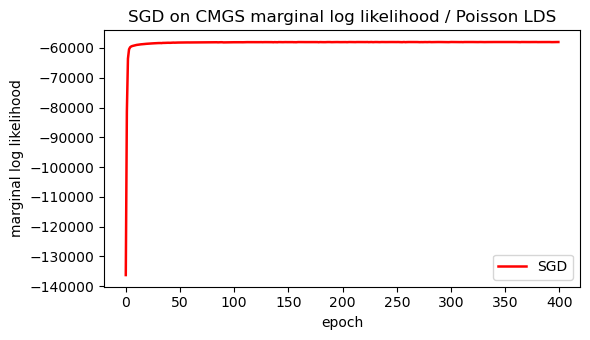

In [35]:
%matplotlib inline 
# Plot loss curve
plt.figure(figsize=(6, 3.5))
plt.plot(-jnp.array(losses), color="r", lw=1.8, label="SGD")
plt.xlabel("epoch"); plt.ylabel("marginal log likelihood")
plt.title("SGD on CMGS marginal log likelihood / Poisson LDS")
plt.legend(); plt.tight_layout()

In [36]:
centers_ms

array([-590.        , -570.        , -550.        , -530.        ,
       -510.        , -490.        , -470.        , -450.        ,
       -430.        , -410.        , -390.        , -370.        ,
       -350.        , -330.        , -310.        , -290.        ,
       -270.        , -250.        , -230.        , -210.        ,
       -190.        , -170.        , -150.        , -130.        ,
       -110.        ,  -90.        ,  -70.        ,  -50.        ,
        -30.        ,   47.93333333,   67.93333333,   87.93333333,
        107.93333333,  127.93333333,  147.93333333,  167.93333333,
        187.93333333,  207.93333333,  227.93333333,  247.93333333,
        267.93333333,  287.93333333,  307.93333333,  327.93333333,
        347.93333333,  367.93333333,  387.93333333,  407.93333333,
        427.93333333,  447.93333333,  467.93333333,  487.93333333,
        507.93333333,  527.93333333,  547.93333333,  567.93333333,
        587.93333333])

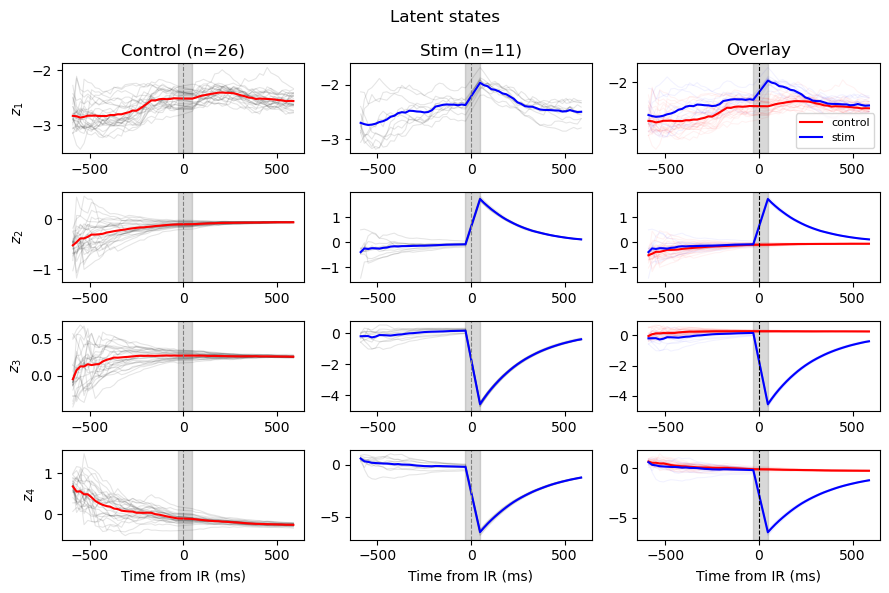

In [37]:
%matplotlib inline

disp_states = 4
disp_states = min(disp_states, z_combined.shape[-1])
z_stim_disp = z_stim[:11, :, :]

n_trials_ctrl = z_control.shape[0]
n_trials_stim = z_stim_disp.shape[0]

mean_ctrl = z_control.mean(axis=0)
mean_stim = z_stim_disp.mean(axis=0)

fig, axs = plt.subplots(disp_states, 3, figsize=(9, 1.5 * disp_states), sharex=False)

for d in range(disp_states):
    # Control (left)
    ax_c = axs[d, 0]
    for i in range(n_trials_ctrl):
        ax_c.plot(centers_ms, z_control[i, :, d], color="k", lw=0.8, alpha=0.1)
    ax_c.plot(centers_ms, mean_ctrl[:, d], color="red", lw=1.5)
    ax_c.axvline(0, color="grey", lw=0.8, ls="--")
    ax_c.set_ylabel(rf"$z_{{{d+1}}}$")
    ax_c.axvspan(centers_ms[ir_idx], centers_ms[ir_idx + 1], color="grey", alpha=0.3)
    if d == 0:
        ax_c.set_title(f"Control (n={n_trials_ctrl})")
    if d == disp_states - 1:
        ax_c.set_xlabel("Time from IR (ms)")

    # Stim (middle)
    ax_s = axs[d, 1]
    for i in range(n_trials_stim):
        ax_s.plot(centers_ms, z_stim_disp[i, :, d], color="k", lw=0.8, alpha=0.1)
    ax_s.plot(centers_ms, mean_stim[:, d], color="blue", lw=1.5)
    ax_s.axvline(0, color="grey", lw=0.8, ls="--")
    ax_s.axvspan(centers_ms[ir_idx], centers_ms[ir_idx + 1], color="grey", alpha=0.3)
    if d == 0:
        ax_s.set_title(f"Stim (n={n_trials_stim})")
    if d == disp_states - 1:
        ax_s.set_xlabel("Time from IR (ms)")

    # Overlay (right)
    ax_o = axs[d, 2]
    for i in range(n_trials_ctrl):
        ax_o.plot(centers_ms, z_control[i, :, d], color="red", lw=0.8, alpha=0.05)
    for i in range(n_trials_stim):
        ax_o.plot(centers_ms, z_stim_disp[i, :, d], color="blue", lw=0.8, alpha=0.05)
    ax_o.plot(centers_ms, mean_ctrl[:, d], color="red",  lw=1.5, label="control")
    ax_o.plot(centers_ms,    mean_stim[:, d], color="blue", lw=1.5, label="stim")
    ax_o.axvline(0, color='k', lw=0.8, ls='--')
    ax_o.axvspan(centers_ms[ir_idx], centers_ms[ir_idx + 1], color="grey", alpha=0.3)
    if d == 0:
        ax_o.set_title("Overlay")
        ax_o.legend(fontsize=8)
    if d == disp_states - 1:
        ax_o.set_xlabel("Time from IR (ms)")

fig.suptitle("Latent states")
plt.tight_layout()

In [38]:
def plot_mean_latents_and_psth(
    z_control, z_stim,
    psth_control, psth_stim,
    edges_ms_control, edges_ms_stim,
    centers_ms_control, centers_ms_stim, ir_idx,
    disp_states=5, vmin=None, vmax=None
):
    n_ch = psth_control.shape[0]
    y_edges = np.arange(n_ch + 1)

    mean_c = z_control.mean(axis=0)
    std_c  = z_control.std(axis=0)
    mean_s = z_stim.mean(axis=0)
    std_s  = z_stim.std(axis=0)

    states_all = np.concatenate([mean_c[:, :disp_states], mean_s[:, :disp_states]], axis=0)
    lim = 1.5 * abs(states_all - states_all.mean(axis=0)).max()
    colors = plt.cm.tab10(np.linspace(0, 1, disp_states))

    fig, axs = plt.subplots(
        2, 2,
        height_ratios=[disp_states, 4],
        figsize=(9, 1 * disp_states + 2),
        constrained_layout=True
    )

    for col, (mean_latents, std_latents, label, centers_ms) in enumerate([
        (mean_c, std_c, f"Control (n={z_control.shape[0]})", centers_ms_control),
        (mean_s, std_s, f"Stim (n={z_stim.shape[0]})",       centers_ms_stim),
    ]):
        ax = axs[0, col]
        for d in range(disp_states):
            offset = -lim * d
            c = colors[d]
            ax.axhline(offset, color='k', ls=':', lw=1)
            mean_d = mean_latents[:, d]
            std_d  = std_latents[:, d]
            mu_c   = mean_d - mean_d.mean()
            ax.fill_between(centers_ms, mu_c - std_d + offset, mu_c + std_d + offset,
                            color=c, alpha=0.25)
            ax.plot(centers_ms, mu_c + offset, color=c, lw=1.5)

        ax.set_yticks(-jnp.arange(disp_states) * lim)
        if col == 0:
            ax.set_yticklabels([rf"$z_{{{d+1}}}$" for d in range(disp_states)])
            ax.axvline(0, color='grey', lw=0.8, ls='--')
        else:
            ax.set_yticklabels([])
            ax.axvline(0, color='grey', lw=0.8, ls='--')
            ax.axvspan(centers_ms[ir_idx], centers_ms[ir_idx + 1], color="grey", alpha=0.3)
        ax.set_xticks([])
        ax.set_xlim(centers_ms[0], centers_ms[-1])
        ax.set_title(label)

    for col, (psth, edges_ms, centers_ms) in enumerate([
        (psth_control, edges_ms_control, centers_ms_control),
        (psth_stim,    edges_ms_stim,    centers_ms_stim),
    ]):
        ax_b = axs[1, col]
        ax_b.set_facecolor("0.5")
        pc = ax_b.pcolormesh(
            edges_ms, y_edges, psth,
            shading="flat", cmap="jet", vmin=vmin, vmax=vmax,
        )
        ax_b.invert_yaxis()
        ax_b.axvline(0, linestyle="--", color="black")
        ax_b.set_ylim(n_ch, 0)
        ax_b.set_xlim(edges_ms[0], edges_ms[-1])
        ax_b.set_xlabel("Time from IR (ms)")
        if col == 0:
            ax_b.set_ylabel("Channel")
        fig.colorbar(pc, ax=ax_b, label="Z", fraction=0.046, pad=0.04)
        
def pad_bins_to_edges(Z, centers_ms, edges_ms, tol=1e-6):
    # Z: (n_ch, n_centers)
    # edges_ms: (n_edges,) -> expects Z to have (n_edges-1) columns
    centers_from_edges = 0.5 * (edges_ms[:-1] + edges_ms[1:])  # (n_edges-1,)
    out = np.full((Z.shape[0], centers_from_edges.size), np.nan, dtype=float)

    # map each provided center to the nearest edge-center
    idx = np.full(centers_ms.size, -1, dtype=int)
    for j, c in enumerate(centers_ms):
        k = int(np.argmin(np.abs(centers_from_edges - c)))
        if abs(centers_from_edges[k] - c) <= tol:
            idx[j] = k

    if np.any(idx < 0):
        bad = centers_ms[idx < 0]
        raise ValueError(f"Some centers did not match edge-centers (tol={tol}): {bad[:10]}")

    out[:, idx] = Z
    return out, centers_from_edges

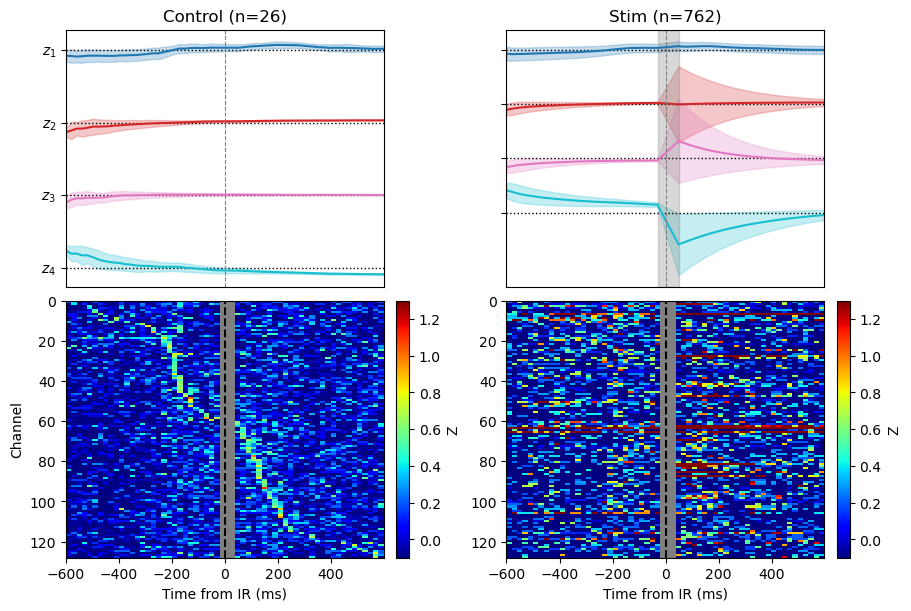

In [39]:
trial = 1

counts_ch_control = all_observations_combined[:26, :, :].transpose(0, 2, 1)
# counts_ch_control: (trials, n_ch, n_bins)
mu_control  = np.nanmean(counts_ch_control, axis=(0, 2), keepdims=False)  # (n_ch,)
sig_control = np.nanstd(counts_ch_control, axis=(0, 2), keepdims=False)  # (n_ch,)
sig_control = np.clip(sig_control, 1e-6, None)

counts_z = (counts_ch_control - mu_control[None, :, None]) / sig_control[None, :, None]
psth_z = np.nanmean(counts_z, axis=0)
X = psth_z
t = centers_ms

# Peak value and peak time (argmax) within the search window
X_finite = np.where(np.isfinite(X), X, -np.inf)
peak_idx = np.argmax(X_finite, axis=1)
peak_time_ms = t[peak_idx]
peak_val = np.max(X_finite, axis=1)

# Keep only neurons with a real response; rest go to bottom
z_thresh = 0  # tune (0.5–1.5 is common)
responsive = np.isfinite(peak_val) & (peak_val >= z_thresh)

order_resp = np.argsort(peak_time_ms[responsive])  # earliest first
order = np.concatenate([np.where(responsive)[0][order_resp],
                        np.where(~responsive)[0]])
psth_ch_sorted = psth_z[order]

psth_control_sorted, _ = pad_bins_to_edges(psth_ch_sorted, centers_ms, edges_ms, tol=1e-3)

counts_ch_stim = all_observations_combined[26:37, :, :].transpose(0, 2, 1)  # (trials, n_ch, n_bins)
counts_ch_stim_zscored = (counts_ch_stim - mu_control[None, :, None]) / sig_control[None, :, None] # z-score each stim trial using control baseline
psth_z_stim = np.nanmean(counts_ch_stim_zscored, axis=0)  # get average trace

psth_stim_sorted, _ = pad_bins_to_edges(psth_z_stim[order], centers_ms, edges_ms, tol=1e-3)

plot_mean_latents_and_psth(
    z_control=z_control,
    z_stim=z_stim,
    psth_control=psth_control_sorted,
    psth_stim=psth_stim_sorted,
    edges_ms_control=edges_ms,
    edges_ms_stim=edges_ms,
    centers_ms_control=centers_ms,
    centers_ms_stim=centers_ms,
    ir_idx=ir_idx,
    disp_states=disp_states,
    vmin=-0.1, vmax=1.3
)

## Reconstruction error

In [13]:
# n_trials, T, obs_dim = innovations_control.shape

# mean_innovation = np.array(innovations_control.mean(axis=0))
# innovations_np  = np.array(innovations_control)

# channel_order = np.argsort(np.abs(mean_innovation).max(axis=0))[::-1]

# fig, axes = plt.subplots(20, 5, figsize=(10, 32), sharex=True, sharey=False)
# axes_flat = axes.flatten()

# for plot_idx, ch in enumerate(channel_order[:99]):
#     ax = axes_flat[plot_idx]
#     for i in range(n_trials):
#         ax.plot(centers_ms, innovations_np[i, :, ch],
#                 color='steelblue', alpha=0.15, linewidth=0.5)
#     ax.plot(centers_ms, mean_innovation[:, ch],
#             color='crimson', linewidth=1.5)
#     ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
#     ax.axvline(0, color='k', linewidth=0.8, linestyle=':')
#     ax.set_title(f'ch {ch+1}', fontsize=9)

# for ax in axes_flat:
#     ax.set_xlabel('Time from IR (ms)', fontsize=8)
#     ax.set_ylabel('Residual', fontsize=8)
#     ax.tick_params(labelsize=7)

# ax = axes_flat[-1]
# mean_across = mean_innovation.mean(axis=-1)
# std_across  = mean_innovation.std(axis=-1)
# ax.fill_between(centers_ms,
#                 mean_across - std_across,
#                 mean_across + std_across,
#                 alpha=0.25, color='steelblue')
# ax.plot(centers_ms, mean_across, color='steelblue', linewidth=1.5)
# ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
# ax.axvline(0, color='k', linewidth=0.8, linestyle=':')
# ax.set_title('mean — all channels', fontsize=9)

# plt.suptitle('Control — one-step-ahead prediction error (ordered)', fontsize=10, y=1.01)
# plt.tight_layout()
# plt.show()

In [41]:
# n_trials, T, obs_dim = innovations_stim.shape

# mean_innovation = np.array(innovations_stim.mean(axis=0))
# innovations_np  = np.array(innovations_stim)

# channel_order = np.argsort(np.abs(mean_innovation).max(axis=0))[::-1]

# fig, axes = plt.subplots(20, 5, figsize=(10, 32), sharex=True, sharey=False)
# axes_flat = axes.flatten()

# for plot_idx, ch in enumerate(channel_order[:99]):
#     ax = axes_flat[plot_idx]
#     for i in range(n_trials):
#         ax.plot(centers_ms, innovations_np[i, :, ch],
#                 color='steelblue', alpha=0.15, linewidth=0.5)
#     ax.plot(centers_ms, mean_innovation[:, ch],
#             color='crimson', linewidth=1.5)
#     ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
#     ax.axvline(0, color='k', linewidth=0.8, linestyle=':')
#     ax.set_title(f'ch {ch+1}', fontsize=9)

# for ax in axes_flat:
#     ax.set_xlabel('Time from IR (ms)', fontsize=8)
#     ax.set_ylabel('Residual', fontsize=8)
#     ax.tick_params(labelsize=7)

# ax = axes_flat[-1]
# mean_across = mean_innovation.mean(axis=-1)
# std_across  = mean_innovation.std(axis=-1)
# ax.fill_between(centers_ms,
#                 mean_across - std_across,
#                 mean_across + std_across,
#                 alpha=0.25, color='steelblue')
# ax.plot(centers_ms, mean_across, color='steelblue', linewidth=1.5)
# ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
# ax.axvline(0, color='k', linewidth=0.8, linestyle=':')
# ax.set_title('mean — all channels', fontsize=9)

# plt.suptitle('Stim — one-step-ahead prediction error (ordered)', fontsize=10, y=1.01)
# plt.tight_layout()
# plt.show()

## Fit prestim only

In [42]:
# Prestim mask (reuse the one already computed)
prestim_mask = centers_ms < 0  # (n_bins,) bool

# Slice observations and inputs to prestim only
all_obs_prestim   = all_observations_combined[:, prestim_mask, :]   # (n_trials, n_prestim_bins, n_ch)
stim_ind_prestim  = stim_ind_combined[:, prestim_mask, :]           # (n_trials, n_prestim_bins, n_ch)
centers_ms_prestim = centers_ms[prestim_mask]

print(f"Fitting on {prestim_mask.sum()} prestim bins out of {len(centers_ms)} total")

Fitting on 29 prestim bins out of 57 total


In [ ]:
key = jr.key(1)
key1, key2 = jr.split(key, 2)
state_dim = 4

num_trials, num_timesteps, n_ch = all_obs_prestim.shape

C_init   = 0.5 * jr.normal(key2, shape=(n_ch, state_dim))
d_init   = jnp.mean(all_observations_combined[trial_labels == 0][:, prestim_mask, :], axis=(0, 1))
log_d_init = jnp.log(jnp.clip(d_init, 1e-6, None))
A_init   = jnp.eye(state_dim)
B_init   = jnp.zeros((state_dim, n_ch)) + 0.01 * jr.normal(key2, shape=(state_dim, n_ch))
mu0_init = jnp.zeros(state_dim)

theta_pre = (C_init, log_d_init, A_init, B_init, mu0_init)

optimizer_pre = optax.adam(1e-2)
opt_state_pre = optimizer_pre.init(theta_pre)

@jit
def step_batch_pre(theta, opt_state, obs_batch, inp_batch):
    loss, grads = value_and_grad(loss_fn)(theta, obs_batch, inp_batch)
    updates, new_opt_state = optimizer_pre.update(grads, opt_state)
    return optax.apply_updates(theta, updates), new_opt_state, loss
        
C_fit_combined, log_d_fit_combined, A_fit_combined, B_fit_combined, mu0_fit_combined = theta

print('singular values of A_fit:', jnp.linalg.svd(A_fit_combined, compute_uv=False))



n_trials_total = all_obs_prestim.shape[0]
indices = jnp.arange(n_trials_total)
losses_pre = []
n_epochs = 400

for epoch in range(n_epochs):
    perm = jr.permutation(jr.key(epoch), indices)
    epoch_loss, n_batches = 0.0, 0
    for start in range(0, n_trials_total, BATCH_SIZE):
        batch_idx  = perm[start:start + BATCH_SIZE]
        obs_batch  = all_obs_prestim[batch_idx]
        inp_batch  = stim_ind_prestim[batch_idx]
        theta_pre, opt_state_pre, loss = step_batch_pre(theta_pre, opt_state_pre, obs_batch, inp_batch)
        epoch_loss += float(loss); n_batches += 1
    losses_pre.append(epoch_loss / n_batches)
    if epoch % 50 == 0:
        C_cur, _, A_cur, B_cur, _ = theta_pre
        print(f"epoch {epoch:4d}  loss={losses_pre[-1]:.2f}  A_norm={jnp.linalg.norm(A_cur):.4f}")

C_fit_pre, log_d_fit_pre, A_fit_pre, B_fit_pre, mu0_fit_pre = theta_pre
print('singular values of A_fit_pre:', jnp.linalg.svd(A_fit_pre, compute_uv=False))

epoch    0  loss=71553.04  A_norm=1.9637
epoch   50  loss=27780.29  A_norm=1.6404
epoch  100  loss=27745.10  A_norm=1.6152
epoch  150  loss=27727.53  A_norm=1.6163
epoch  200  loss=27717.75  A_norm=1.6319
epoch  250  loss=27697.26  A_norm=1.6911
epoch  300  loss=27694.69  A_norm=1.6827
epoch  350  loss=27692.95  A_norm=1.6664
singular values of A_fit_pre: [1.006221   0.96188664 0.85613114 0.15506351]


In [54]:
# Get latent trajectories
params_prestim = make_params(C_fit_pre, jnp.exp(log_d_fit_pre), A_fit_pre, B_fit_pre, mu0_fit_pre)
# Run smoother on prestim bins only
posts_prestim = vmap(lambda obs, input: cmgs(params_prestim, EKFIntegrals(), obs, inputs=input))(
    all_obs_prestim, stim_ind_prestim  # prestim-sliced, not full
)

U, S, Vt = jnp.linalg.svd(C_fit_pre, full_matrices=False)
R = Vt.T

z_combined_prestim = posts_prestim.filtered_means @ R

In [55]:
unique_sessions = jnp.unique(session_labels)

obs_by_session      = {}
stim_ind_by_session = {}
posts_by_session    = {}
z_by_session        = {}
predicted_by_session    = {}
innovations_by_session  = {}

for sess_idx in unique_sessions:
    mask = session_labels == sess_idx
    sess_idx = int(sess_idx)
    obs_by_session[sess_idx]          = all_observations_combined[mask]
    stim_ind_by_session[sess_idx]     = stim_ind_combined[mask]
    posts_by_session[sess_idx] = jax.tree.map(lambda x: x[mask], posts_prestim)        # correct
    z_by_session[sess_idx]            = z_combined[mask]
    predicted_by_session[sess_idx]    = predicted_all_combined[mask]
    innovations_by_session[sess_idx]  = innovations_all_combined[mask]

# Keep control/stim split as well for convenience
control_mask = trial_labels == 0
stim_mask    = trial_labels == 1

z_control = z_combined[control_mask]
z_stim    = z_combined[stim_mask]
innovations_control = innovations_all_combined[control_mask]
innovations_stim    = innovations_all_combined[stim_mask]

In [56]:
prestim_mask = centers_ms < 0

# Split by session
z_by_session_prestim = {}
for sess_idx in jnp.unique(session_labels):
    mask = session_labels == sess_idx
    z_by_session_prestim[int(sess_idx)] = z_combined_prestim[mask]

centers_ms_by_session_prestim = {
    k: v[prestim_mask]
    for k, v in centers_ms_by_session.items()
}

fig = plot_latent_phase_portrait_sessions(
    z_by_session=z_by_session_prestim,
    centers_ms_by_session=centers_ms_by_session_prestim,
    control_indices=CONTROL_INDICES,
    alpha_trials=0.05,
    plot_sessions=None,
    epoch="full",  # no gap in prestim-only data, so "full" is correct
    show_pre_post=False,
    show_trials=False,
    show_markers=False,
)
fig.show()